# Credit Risk Prediction

In [67]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [68]:
DATA_PATHS = [Path("data/UCI_Credit_Card.csv"), Path("UCI_Credit_Card.csv")]
for p in DATA_PATHS:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("UCI_Credit_Card.csv was not found.")

df = pd.read_csv(data_path)
if "ID" in df.columns:
    df = df.drop(columns=["ID"])
target_col = "default.payment.next.month"

print(f"Loaded: {data_path} | Shape: {df.shape}")
display(df.head())

Loaded: UCI_Credit_Card.csv | Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Dataset overview (column-by-column)

This section helps us understand what values each column contains before cleaning and modeling.
- For low-cardinality columns: show all unique values.
- For high-cardinality columns: show number of unique values and sample values.

In [69]:
overview_rows = []

for col in df.columns:
    non_null = df[col].dropna()
    n_unique = non_null.nunique()
    dtype = str(df[col].dtype)

    # Show full unique list only when the column has a small number of categories
    if n_unique <= 12:
        values_preview = sorted(non_null.unique().tolist())
    else:
        values_preview = non_null.astype(str).unique()[:8].tolist()

    overview_rows.append(
        {
            "column": col,
            "dtype": dtype,
            "n_unique": int(n_unique),
            "example_or_unique_values": values_preview,
        }
    )

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

print("\nTip: columns with very high n_unique (like IDs) are usually not useful as predictive features.")

,column,dtype,n_unique,example_or_unique_values
0,LIMIT_BAL,float64,81,"[20000.0, 120000.0, 90000.0, 50000.0, 500000.0..."
1,SEX,int64,2,"[1, 2]"
2,EDUCATION,int64,7,"[0, 1, 2, 3, 4, 5, 6]"
3,MARRIAGE,int64,4,"[0, 1, 2, 3]"
4,AGE,int64,56,"[24, 26, 34, 37, 57, 29, 23, 28]"
5,PAY_0,int64,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
6,PAY_2,int64,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
7,PAY_3,int64,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
8,PAY_4,int64,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
9,PAY_5,int64,10,"[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]"



Tip: columns with very high n_unique (like IDs) are usually not useful as predictive features.


## Data quality and EDA

We keep this part short and visual so it is easy to explain in class.

Shape: (30000, 24)

Data types:
float64    13
int64      11
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 35

Unique values in EDUCATION: [0, 1, 2, 3, 4, 5, 6]
Unique values in MARRIAGE: [0, 1, 2, 3]

PAY_* value ranges:


,min,max,n_unique
PAY_0,-2.0,8.0,11
PAY_2,-2.0,8.0,11
PAY_3,-2.0,8.0,11
PAY_4,-2.0,8.0,11
PAY_5,-2.0,8.0,10
PAY_6,-2.0,8.0,10
PAY_AMT1,0.0,873552.0,7943
PAY_AMT2,0.0,1684259.0,7899
PAY_AMT3,0.0,896040.0,7518
PAY_AMT4,0.0,621000.0,6937


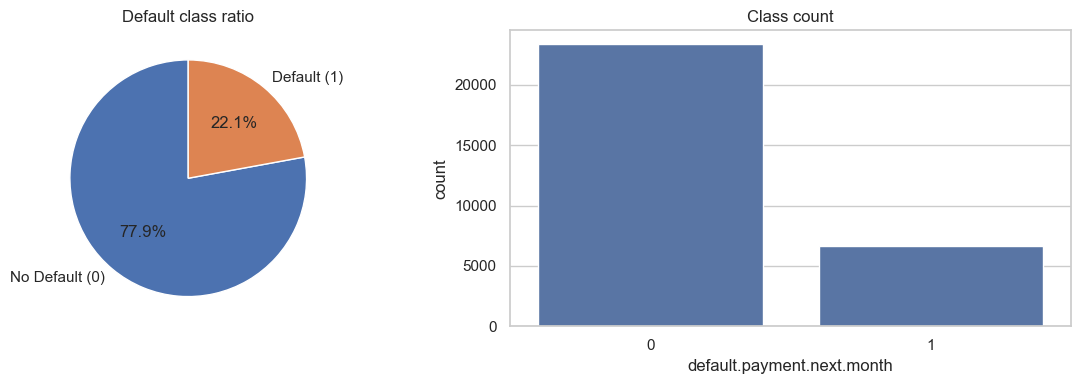

In [70]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# Check unusual category codes before cleaning
print("\nUnique values in EDUCATION:", sorted(df["EDUCATION"].unique().tolist()))
print("Unique values in MARRIAGE:", sorted(df["MARRIAGE"].unique().tolist()))

# Quick profile for payment status columns
pay_status_cols = [c for c in df.columns if c.startswith("PAY_") and c != target_col]
if pay_status_cols:
    print("\nPAY_* value ranges:")
    pay_profile = pd.DataFrame({
        "min": df[pay_status_cols].min(),
        "max": df[pay_status_cols].max(),
        "n_unique": df[pay_status_cols].nunique(),
    })
    display(pay_profile)

class_counts = df[target_col].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(class_counts.values, labels=["No Default (0)", "Default (1)"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("Default class ratio")

sns.countplot(data=df, x=target_col, ax=axes[1])
axes[1].set_title("Class count")
plt.tight_layout()
plt.show()

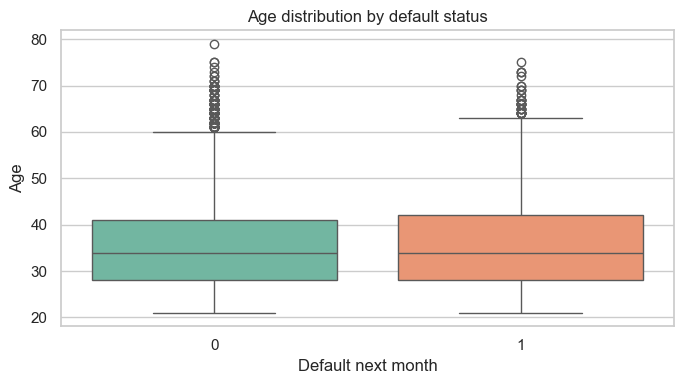

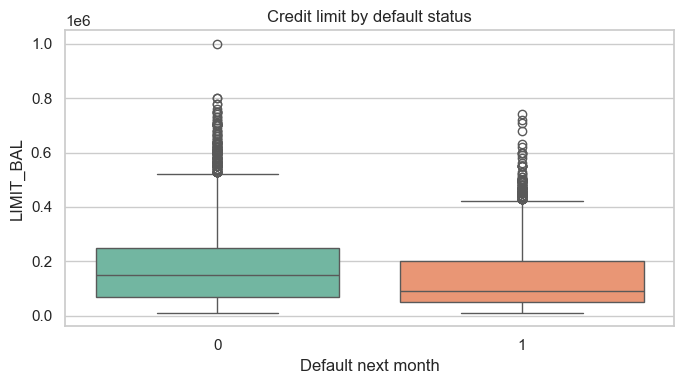

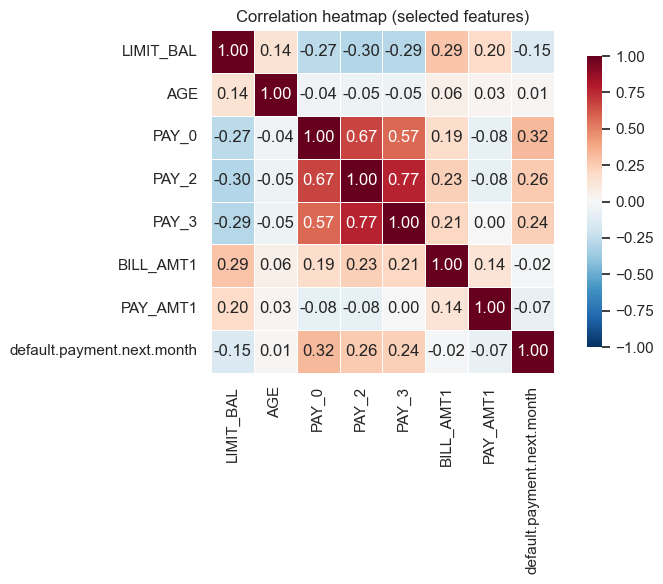

In [71]:
# 1) AGE by target
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x=target_col, y="AGE", palette="Set2")
plt.title("Age distribution by default status")
plt.xlabel("Default next month")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# 2) LIMIT_BAL by target
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x=target_col, y="LIMIT_BAL", palette="Set2")
plt.title("Credit limit by default status")
plt.xlabel("Default next month")
plt.ylabel("LIMIT_BAL")
plt.tight_layout()
plt.show()

# 3) Correlation heatmap
corr_cols = ["LIMIT_BAL", "AGE", "PAY_0", "PAY_2", "PAY_3", "BILL_AMT1", "PAY_AMT1", target_col]
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(8.5, 6))
sns.heatmap(
    df[corr_cols].corr(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.85},
)
plt.title("Correlation heatmap (selected features)")
plt.tight_layout()
plt.show()

### Categorical feature 1: SEX

This chart shows default rate for each gender code in the dataset.

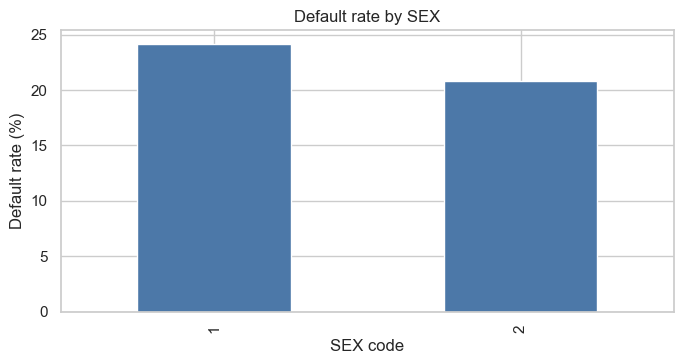

,default_rate_pct
SEX,
1,24.167227
2,20.776281


In [72]:
sex_rate = df.groupby("SEX")[target_col].mean().sort_index() * 100
plt.figure(figsize=(7, 3.8))
sex_rate.plot(kind="bar", color="#4C78A8")
plt.title("Default rate by SEX")
plt.xlabel("SEX code")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()
sex_rate.to_frame("default_rate_pct")

### Categorical feature 2: EDUCATION

This chart helps us see which education group has higher default tendency.

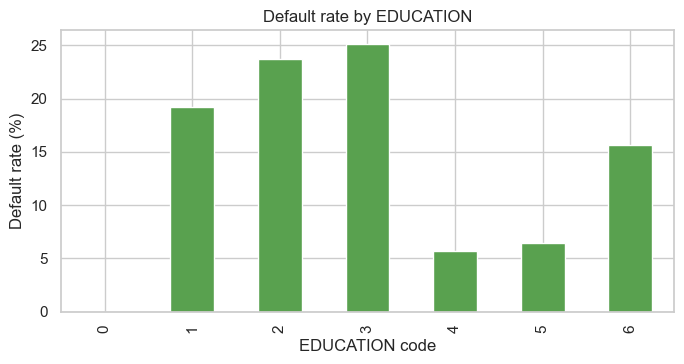

,default_rate_pct
EDUCATION,
0,0.000000
1,19.234766
2,23.734854
3,25.157616
4,5.691057
5,6.428571
6,15.686275


In [73]:
edu_rate = df.groupby("EDUCATION")[target_col].mean().sort_index() * 100
plt.figure(figsize=(7, 3.8))
edu_rate.plot(kind="bar", color="#59A14F")
plt.title("Default rate by EDUCATION")
plt.xlabel("EDUCATION code")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()
edu_rate.to_frame("default_rate_pct")

### Categorical feature 3: MARRIAGE

This chart shows the relationship between marital status code and default rate.

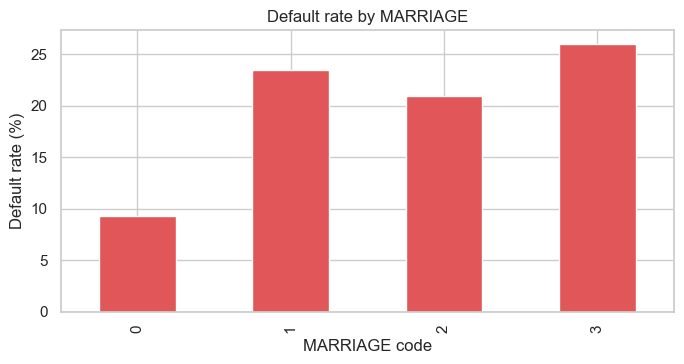

,default_rate_pct
MARRIAGE,
0,9.259259
1,23.471704
2,20.928339
3,26.006192


In [74]:
mar_rate = df.groupby("MARRIAGE")[target_col].mean().sort_index() * 100
plt.figure(figsize=(7, 3.8))
mar_rate.plot(kind="bar", color="#E15759")
plt.title("Default rate by MARRIAGE")
plt.xlabel("MARRIAGE code")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()
mar_rate.to_frame("default_rate_pct")

In [75]:
# EDA summary values for reporting
class_pct = df[target_col].value_counts(normalize=True).sort_index() * 100
sex_gap = float(sex_rate.max() - sex_rate.min())
edu_gap = float(edu_rate.max() - edu_rate.min())
mar_gap = float(mar_rate.max() - mar_rate.min())

print("Default rate summary (%):")
print(class_pct.round(2))
print(f"\nDefault-rate gap by SEX: {sex_gap:.2f} percentage points")
print(f"Default-rate gap by EDUCATION: {edu_gap:.2f} percentage points")
print(f"Default-rate gap by MARRIAGE: {mar_gap:.2f} percentage points")

Default rate summary (%):
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

Default-rate gap by SEX: 3.39 percentage points
Default-rate gap by EDUCATION: 25.16 percentage points
Default-rate gap by MARRIAGE: 16.75 percentage points


### EDA interpretation (presentation style)

- The target is imbalanced: non-default customers are the majority.
- This imbalance explains why we later use balanced settings in some models.
- AGE and LIMIT_BAL plots show visible distribution differences between class 0 and class 1.
- Categorical default-rate charts show that risk level is not identical across demographic groups.
- In short: both profile information and payment behavior should be considered, not only one variable.

### EDA conclusion (before preprocessing)

The main message from EDA is simple:
- the dataset is imbalanced,
- demographic groups have different default rates,
- and payment behavior shows strong risk patterns.

So in the next step, we clean data and engineer features that capture these patterns.

## Payment behavior analysis (key risk signals)

This part focuses on repayment behavior, which is usually the strongest signal for default prediction.

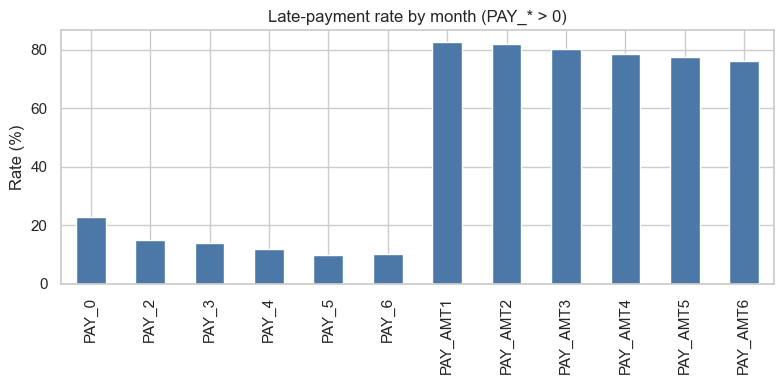

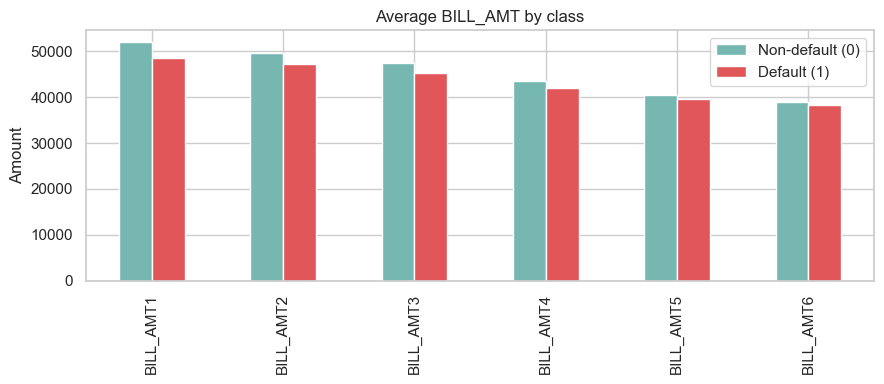

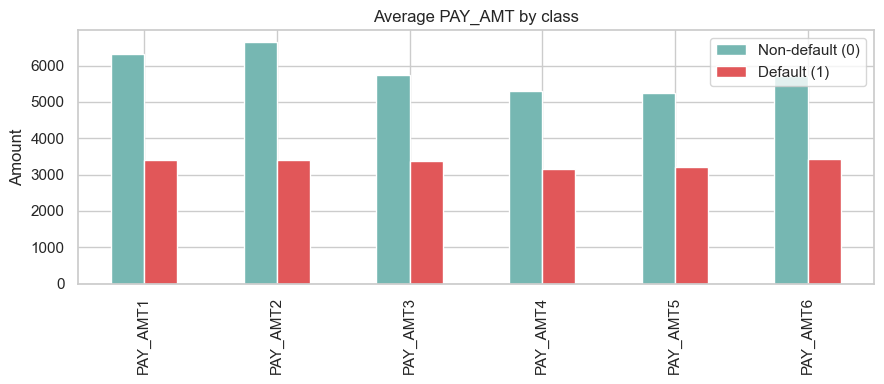

In [76]:
pay_cols = [c for c in df.columns if c.startswith("PAY_") and c != target_col]
bill_cols = [c for c in df.columns if c.startswith("BILL_AMT")]
pay_amt_cols = [c for c in df.columns if c.startswith("PAY_AMT")]

# 1) Late-payment rate by month
late_rate = (df[pay_cols] > 0).mean().sort_index() * 100
plt.figure(figsize=(8, 4))
late_rate.plot(kind="bar", color="#4C78A8")
plt.title("Late-payment rate by month (PAY_* > 0)")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()

# 2) Bill amount comparison: default vs non-default
bill_compare = pd.DataFrame({
    "Non-default (0)": df[df[target_col] == 0][bill_cols].mean(),
    "Default (1)": df[df[target_col] == 1][bill_cols].mean(),
})
bill_compare.plot(kind="bar", figsize=(9, 4), color=["#76B7B2", "#E15759"])
plt.title("Average BILL_AMT by class")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

# 3) Payment amount comparison: default vs non-default
pay_compare = pd.DataFrame({
    "Non-default (0)": df[df[target_col] == 0][pay_amt_cols].mean(),
    "Default (1)": df[df[target_col] == 1][pay_amt_cols].mean(),
})
pay_compare.plot(kind="bar", figsize=(9, 4), color=["#76B7B2", "#E15759"])
plt.title("Average PAY_AMT by class")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

### Payment behavior interpretation

- Higher late-payment rate means customers already show repayment stress.
- If default group has higher bill amounts but lower payment amounts, repayment pressure is likely increasing.
- This directly supports creating behavior features such as `AVG_PAY_DELAY`, `UTIL_RATIO`, and `PAY_TO_BILL_RATIO`.

## Preprocessing

The data is imbalanced, so we will track Accuracy, Precision, Recall, and F1-score.
For some models, we use `class_weight="balanced"`.

In [77]:
clean_df = df.copy()

# 1) Fix uncommon category codes
clean_df["EDUCATION"] = clean_df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
clean_df["MARRIAGE"] = clean_df["MARRIAGE"].replace({0: 3})

# 2) Basic feature groups
pay_cols = [c for c in clean_df.columns if c.startswith("PAY_") and c != target_col]
bill_cols = [c for c in clean_df.columns if c.startswith("BILL_AMT")]
pay_amt_cols = [c for c in clean_df.columns if c.startswith("PAY_AMT")]

# 3) Outlier handling for money columns (simple and student-friendly)
money_cols = ["LIMIT_BAL"] + bill_cols + pay_amt_cols
for col in money_cols:
    lower = clean_df[col].quantile(0.01)
    upper = clean_df[col].quantile(0.99)
    clean_df[col] = clean_df[col].clip(lower, upper)

# 4) Feature engineering
clean_df["AVG_BILL"] = clean_df[bill_cols].mean(axis=1)
clean_df["AVG_PAY_AMT"] = clean_df[pay_amt_cols].mean(axis=1)
clean_df["UTIL_RATIO"] = clean_df["AVG_BILL"] / clean_df["LIMIT_BAL"].replace(0, np.nan)
clean_df["PAY_TO_BILL_RATIO"] = clean_df["AVG_PAY_AMT"] / clean_df["AVG_BILL"].replace(0, np.nan)
clean_df["AVG_PAY_DELAY"] = clean_df[pay_cols].mean(axis=1)
clean_df["MAX_PAY_DELAY"] = clean_df[pay_cols].max(axis=1)
clean_df = clean_df.replace([np.inf, -np.inf], np.nan)

# 5) Final check after preprocessing
print("Missing values after processing:", int(clean_df.isna().sum().sum()))
print("EDUCATION values after cleaning:", sorted(clean_df["EDUCATION"].unique().tolist()))
print("MARRIAGE values after cleaning:", sorted(clean_df["MARRIAGE"].unique().tolist()))

# 6) Train-test split
X = clean_df.drop(columns=[target_col])
y = clean_df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 7) Preprocessing pipeline
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = []
print("Train/Test shape:", X_train.shape, X_test.shape)

Missing values after processing: 866
EDUCATION values after cleaning: [1, 2, 3, 4]
MARRIAGE values after cleaning: [1, 2, 3]
Train/Test shape: (24000, 29) (6000, 29)


### Why these preprocessing steps matter

- We fix uncommon category codes (`EDUCATION`, `MARRIAGE`) so categories are consistent.
- We clip extreme monetary outliers (1st-99th percentile) to reduce noise from very large values.
- We create behavior-based features (`UTIL_RATIO`, `PAY_TO_BILL_RATIO`, payment delay features).
- We split train/test with stratification to keep default ratio similar in both sets.
- We use one preprocessing pipeline for all models so comparison is fair.

In [78]:
# We store each model result in this list for final comparison
scores = []

## Model 1 - Logistic Regression

=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.8686    0.6933    0.7712      4673
           1     0.3687    0.6307    0.4654      1327

    accuracy                         0.6795      6000
   macro avg     0.6187    0.6620    0.6183      6000
weighted avg     0.7581    0.6795    0.7035      6000



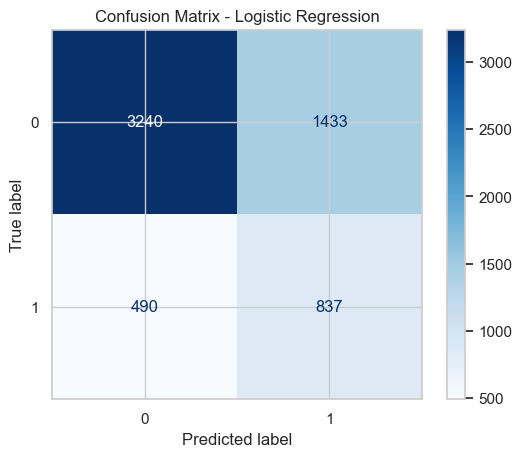

In [79]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

lr_cv_f1 = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]

scores.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1-score": f1_score(y_test, lr_pred),
    "CV F1": lr_cv_f1,
    "ROC-AUC": roc_auc_score(y_test, lr_prob),
})

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Logistic Regression interpretation

- This is a strong and interpretable baseline model.
- With `class_weight="balanced"`, it gives more attention to the minority default class.
- If Recall and F1 are already good here, the data processing pipeline is likely working well.

## Model 2 - KNN

=== KNN ===
              precision    recall  f1-score   support

           0     0.8311    0.9435    0.8837      4673
           1     0.6201    0.3248    0.4263      1327

    accuracy                         0.8067      6000
   macro avg     0.7256    0.6341    0.6550      6000
weighted avg     0.7844    0.8067    0.7826      6000



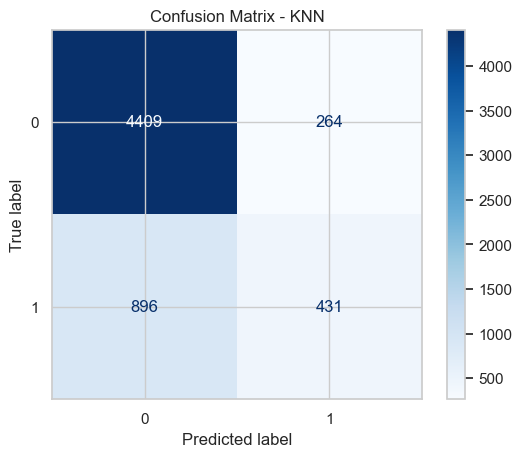

In [80]:
knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15)),
])

knn_cv_f1 = cross_val_score(knn_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)
knn_prob = knn_pipe.predict_proba(X_test)[:, 1]

scores.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred),
    "Recall": recall_score(y_test, knn_pred),
    "F1-score": f1_score(y_test, knn_pred),
    "CV F1": knn_cv_f1,
    "ROC-AUC": roc_auc_score(y_test, knn_prob),
})

print("=== KNN ===")
print(classification_report(y_test, knn_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, knn_pred, cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.show()

### KNN interpretation

- KNN predicts based on nearest similar customers.
- Scaling is important for KNN, so StandardScaler in preprocessing is necessary.
- If KNN has low Recall, it means local neighborhoods are not separating defaults well.

## Model 3 - Naive Bayes

=== Naive Bayes ===
              precision    recall  f1-score   support

           0     0.8868    0.3771    0.5291      4673
           1     0.2746    0.8304    0.4127      1327

    accuracy                         0.4773      6000
   macro avg     0.5807    0.6038    0.4709      6000
weighted avg     0.7514    0.4773    0.5034      6000



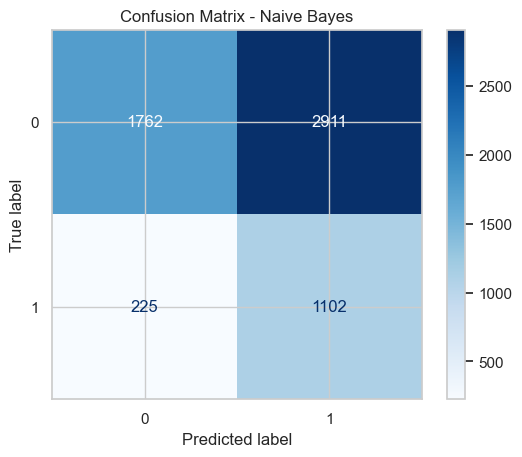

In [81]:
nb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB()),
])

nb_cv_f1 = cross_val_score(nb_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
nb_pipe.fit(X_train, y_train)
nb_pred = nb_pipe.predict(X_test)
nb_prob = nb_pipe.predict_proba(X_test)[:, 1]

scores.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, nb_pred),
    "Precision": precision_score(y_test, nb_pred),
    "Recall": recall_score(y_test, nb_pred),
    "F1-score": f1_score(y_test, nb_pred),
    "CV F1": nb_cv_f1,
    "ROC-AUC": roc_auc_score(y_test, nb_prob),
})

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, nb_pred, cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

### Naive Bayes interpretation

- Naive Bayes is simple and fast, so it works as a strong baseline.
- It assumes feature independence, which may not hold perfectly here.
- If performance is lower, this tells us feature relationships matter in credit risk data.

## Model 4 - SVM

In [82]:
# svm_pipe = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
# ])

# svm_cv_f1 = cross_val_score(svm_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
# svm_pipe.fit(X_train, y_train)
# svm_pred = svm_pipe.predict(X_test)
# svm_prob = svm_pipe.predict_proba(X_test)[:, 1]

# scores.append({
#     "Model": "SVM",
#     "Accuracy": accuracy_score(y_test, svm_pred),
#     "Precision": precision_score(y_test, svm_pred),
#     "Recall": recall_score(y_test, svm_pred),
#     "F1-score": f1_score(y_test, svm_pred),
#     "CV F1": svm_cv_f1,
#     "ROC-AUC": roc_auc_score(y_test, svm_prob),
# })

# print("=== SVM ===")
# print(classification_report(y_test, svm_pred, digits=4))
# ConfusionMatrixDisplay.from_predictions(y_test, svm_pred, cmap="Blues")
# plt.title("Confusion Matrix - SVM")
# plt.show()

### SVM interpretation

- SVM can model more complex boundaries between default and non-default groups.
- It is often strong on classification, but can be slower and harder to explain.
- We still compare it fairly using the same metrics as other models.

## Model 5 - Decision Tree

=== Decision Tree ===
              precision    recall  f1-score   support

           0     0.8704    0.8190    0.8439      4673
           1     0.4722    0.5705    0.5167      1327

    accuracy                         0.7640      6000
   macro avg     0.6713    0.6947    0.6803      6000
weighted avg     0.7823    0.7640    0.7715      6000



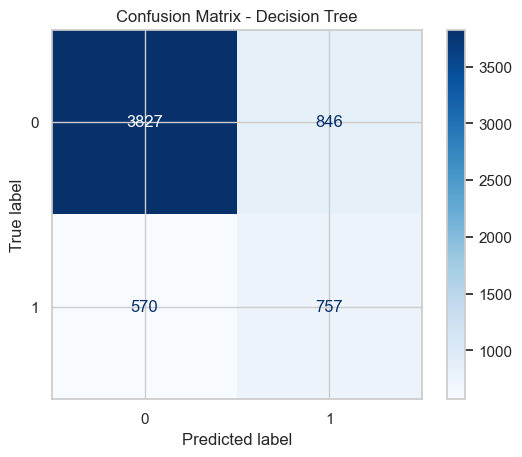

In [83]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight="balanced", random_state=RANDOM_STATE)),
])

dt_cv_f1 = cross_val_score(dt_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
dt_pipe.fit(X_train, y_train)
dt_pred = dt_pipe.predict(X_test)
dt_prob = dt_pipe.predict_proba(X_test)[:, 1]

scores.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1-score": f1_score(y_test, dt_pred),
    "CV F1": dt_cv_f1,
    "ROC-AUC": roc_auc_score(y_test, dt_prob),
})

print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, dt_pred, cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Decision Tree interpretation

- Decision Tree is easy to understand and good for explaining split logic.
- But it can overfit if too deep, so we limit depth and minimum leaf size.
- Compare its Recall/F1 with other models to see if interpretability costs performance.

## Model 6 - Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

           0     0.8773    0.8297    0.8528      4673
           1     0.4965    0.5916    0.5399      1327

    accuracy                         0.7770      6000
   macro avg     0.6869    0.7106    0.6964      6000
weighted avg     0.7931    0.7770    0.7836      6000



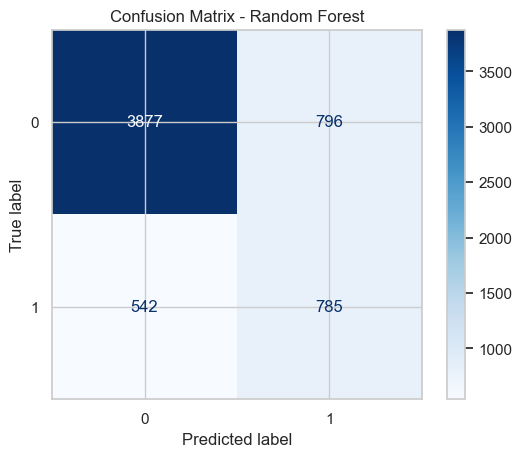

In [84]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_cv_f1 = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_prob = rf_pipe.predict_proba(X_test)[:, 1]

scores.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1-score": f1_score(y_test, rf_pred),
    "CV F1": rf_cv_f1,
    "ROC-AUC": roc_auc_score(y_test, rf_prob),
})

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Random Forest interpretation

- Random Forest usually handles nonlinear relationships better than a single tree.
- If Recall/F1 improves here, it means ensemble learning captures default patterns more effectively.
- If not, simpler models may already be enough for this dataset.

## Comparison table (Model / Accuracy / Precision / Recall / F1-score)

In [85]:
results_df = pd.DataFrame(scores).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score", "CV F1", "ROC-AUC"]]
results_df.style.format({c: "{:.4f}" for c in results_df.columns if c != "Model"})

,Model,Accuracy,Precision,Recall,F1-score,CV F1,ROC-AUC
0,Random Forest,0.7770,0.4965,0.5916,0.5399,0.5458,0.7795
1,Decision Tree,0.7640,0.4722,0.5705,0.5167,0.5259,0.7603
2,Logistic Regression,0.6795,0.3687,0.6307,0.4654,0.4817,0.7156
3,KNN,0.8067,0.6201,0.3248,0.4263,0.4231,0.7370
4,Naive Bayes,0.4773,0.2746,0.8304,0.4127,0.4149,0.7113


### How to read the table

- Accuracy: overall correct predictions.
- Precision: among predicted defaults, how many are truly default.
- Recall: among real defaults, how many the model catches.
- F1-score: balance between Precision and Recall (main metric here).
- ROC-AUC: ranking quality of predicted probabilities.

## Simple sample prediction (best model)

In [86]:
model_pipelines = {
    "Logistic Regression": lr_pipe,
    "KNN": knn_pipe,
    "Naive Bayes": nb_pipe,
    # "SVM": svm_pipe,
    "Decision Tree": dt_pipe,
    "Random Forest": rf_pipe,
}

best_name = results_df.iloc[0]["Model"]
best_pipe = model_pipelines[best_name]

sample_X = X_test.head(5)
sample_prob = best_pipe.predict_proba(sample_X)[:, 1]
sample_pred = (sample_prob >= 0.5).astype(int)

sample_out = pd.DataFrame({
    "pred_prob_default": sample_prob,
    "pred_label": sample_pred,
    "actual": y_test.head(5).values,
}, index=sample_X.index)

print("Best model:", best_name)
display(sample_out)

Best model: Random Forest


,pred_prob_default,pred_label,actual
6907,0.312387,0,0
24575,0.364624,0,0
26766,0.402395,0,0
2156,0.348792,0,1
3179,0.120610,0,0


### How to explain this part in class

- We pick the best model based on F1-score (balance between Precision and Recall).
- Then we predict on a few test samples to show how the model outputs probability and final label.
- This makes the model result easier to understand, not only a technical score table.